# Hi-C data analysis workshop (part 2: cooler interface)

Aurèle Piazza, Romain Bulteau

09/2026

---

## Overview
In this section, we will see how to

 - load `.cool`and `.mcool` files with the [`cooler`](https://cooler.readthedocs.io/en/latest/) python API
 - do basic manipulation and plotting of Hi-C data from cool objects.

Material from this section is adapted from the [cooler docs on visualization](https://cooltools.readthedocs.io/en/latest/notebooks/viz.html).


## Setup

Since each notebook is in its own environment, we need to install the dependencies and fetch the data we need for the course at the start of each notebook.

You can go to the Table of contents (on the left) and click the 'play' symbol next to the Setup section to run the whole section at once.

### Install & check dependencies

In [1]:
!pip install cooler

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.3/109.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 36.8 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=8feb2a2015490ea843e26e0060e77bbaba033a2f22621ed305f8af53da127f0b
  Stored in directory: /root/.cache/pip/wheels/0e/70/f0/bff6301cfa0d49afa79c020bc98c114a9b9c6b3048e62e3200
Successfully built asciitree


In [2]:
import cooler
import numpy as np
import os
from matplotlib import pyplot as plt

# version check
print(f"cooler: {cooler.__version__}")
print(f"numpy: {np.__version__}")

cooler: 0.10.4
numpy: 2.1.3


### Download course data

In [3]:
# path to a folder on your drive where data will be saved
inputdir="hic_data/"
os.makedirs(inputdir, exist_ok=True) # create dir if not exist

# URLs to fetch the data
hicstuff_output_url = "https://sdrive.cnrs.fr/public.php/dav/files/xbqPnPwdEg7WMFd"

In [4]:
# subfolders with unzipped data (don't modify)
hicstuff_output_folder = f"{inputdir}/AD281_0.02_subsamp/"
cool_folder = f"{inputdir}/cool/"


# download & unzip data if subfolders are missing
if not os.path.isdir(hicstuff_output_folder):
  !wget {hicstuff_output_url}/?accept=zip -O {inputdir}/hcs_data.zip
  !unzip {inputdir}/hcs_data.zip -d {inputdir}


--2026-09-02 12:56:28--  https://sdrive.cnrs.fr/public.php/dav/files/xbqPnPwdEg7WMFd/?accept=zip
Resolving sdrive.cnrs.fr (sdrive.cnrs.fr)... 193.55.86.34
Connecting to sdrive.cnrs.fr (sdrive.cnrs.fr)|193.55.86.34|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘hic_data//hcs_data.zip’

hic_data//hcs_data.     [              <=>   ]  63.85M  2.14MB/s    in 52s     

2026-09-02 12:57:21 (1.24 MB/s) - ‘hic_data//hcs_data.zip’ saved [66952345]

Archive:  hic_data//hcs_data.zip
   creating: hic_data/AD281_0.02_subsamp/
   creating: hic_data/AD281_0.02_subsamp/plots/
 extracting: hic_data/AD281_0.02_subsamp/plots/event_distribution.pdf  
 extracting: hic_data/AD281_0.02_subsamp/plots/distance_law.pdf  
 extracting: hic_data/AD281_0.02_subsamp/plots/event_distance.pdf  
 extracting: hic_data/AD281_0.02_subsamp/plots/frags_hist.pdf  
 extracting: hic_data/AD281_0.02_subsamp/info_contigs.txt  
 extracting: hic_data/AD281_0.02_s

----


## Sample loading

In [5]:
# path to the 'Cool' folder from the hicstuff pipeline
hcs_folder=f"{hicstuff_output_folder}/Cool/"
hcs_sample="AD281_0.02_subsamp_S288c_DSB_chr3_rDNA_parasplit_q20_v324"

# path to a folder on your drive where files/plots will be saved
outputdir="outputs/part2/"
os.makedirs(outputdir, exist_ok=True) # create dir if not exist

# color map for plotting
cmap = plt.get_cmap("YlOrBr")
cmap.set_bad('white')

## Loading a `.cool` file

The hicstuff pipeline we just ran generated two files in the `Cool/` output folder:

 - a cool file, ending with `_1kb.cool`
 - a multicool file, ending with `.mcool` (which we'll use in the next section).

We'll load the cool file using the cooler python API.

In [6]:
# path to the cool file
cool_file=f'{hcs_folder}{hcs_sample}_1kb.cool'

c = cooler.Cooler(cool_file)

print(c)

<Cooler "AD281_0.02_subsamp_S288c_DSB_chr3_rDNA_parasplit_q20_v324_1kb.cool::/">


### Object contents and handling

In [7]:
# print the chr names and bin size
print(f'chromosomes: {c.chromnames}')
print(f'binsize: {c.binsize}')

chromosomes: ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', '2_micron', 'mitochondrion']
binsize: 1000


In [8]:
# print the top-left corner of the matrix
print(c.matrix(balance=False)[0:10,0:10])

[[ 3  3  4  3  1  6  4  1  7  1]
 [ 3  2  8  6  0  2  4  2  2  1]
 [ 4  8  2  5  2  4  7  1  3  0]
 [ 3  6  5  3  3 11  6  1  5  2]
 [ 1  0  2  3  0  4  2  2  5  5]
 [ 6  2  4 11  4  0  4  1  7  5]
 [ 4  4  7  6  2  4  2  4 20  4]
 [ 1  2  1  1  2  1  4  0  5  3]
 [ 7  2  3  5  5  7 20  5 11 11]
 [ 1  1  0  2  5  5  4  3 11  1]]


In [9]:
# fetch the c.matrix coordinates of a chr with c.extent()
print(c.extent("chr5"))

# fetch a specific region
print(c.extent("chr5:120,000-250,000"))

(np.int64(2892), np.int64(3471))
(np.int64(3012), np.int64(3142))


### Simple matrix plotting

0 1360


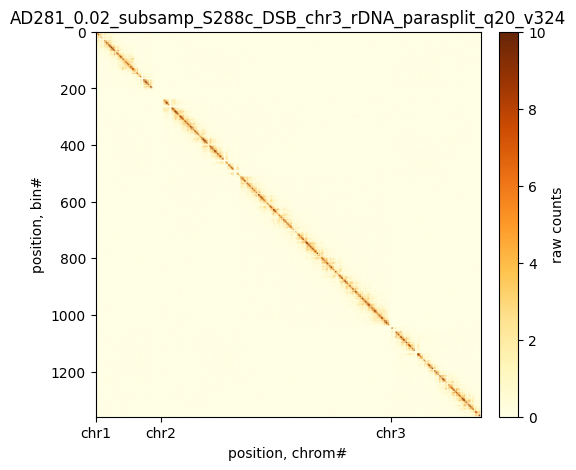

In [10]:
chrs=["chr1", "chr2", "chr3"] # (consecutive) chr to plot

# extract bin indices
exts  = [c.extent(ch) for ch in chrs]
start = np.min(exts)
end   = np.max(exts)

print(start, end)

# create plot area
f, ax = plt.subplots(figsize=(6,5))
# add matrix
im = ax.imshow(c.matrix(balance=False)[start:end, start:end],
               cmap = cmap, vmax=10);
# define axes / labels
ax.set(xticks=[e[0] for e in exts], xticklabels=chrs,
       xlabel='position, chrom#', ylabel='position, bin#')
ax.xaxis.set_label_position('bottom')
ax.set_title(hcs_sample)
# add legend
f.colorbar(im ,fraction=0.046, pad=0.04, label='raw counts')

# save/show
f.savefig(str(outputdir + hcs_sample + '_'.join(chrs) + "_cool_1kb" + ".pdf"), format="pdf", dpi=300)
f.show()

## Loading a `.mcool` file


In [11]:
# path to the mcool file
mcool_file=f'{hcs_folder}{hcs_sample}.mcool'

# list_coolers can be used to print which resolutions are stored in the mcool file
cooler.fileops.list_coolers(mcool_file)

['/resolutions/1000',
 '/resolutions/2000',
 '/resolutions/5000',
 '/resolutions/10000',
 '/resolutions/15000',
 '/resolutions/20000']

In [12]:
# a cooler with a specific resolution can be loaded with:
c = cooler.Cooler(f'{mcool_file}::resolutions/10000')

Check the chromsome names and binsize of the loaded cool

In [13]:
# your code here

In [14]:
# Answer
# to print chromosomes and binsize for this cooler
print(f'chromosomes: {c.chromnames}')
print(f'binsize: {c.binsize}')

chromosomes: ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', '2_micron', 'mitochondrion']
binsize: 10000


<br>

We can plot it using the same code as above

0 137


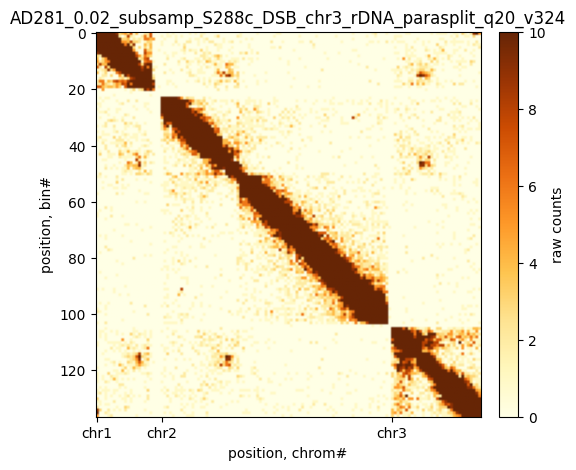

In [15]:
chrs=["chr1", "chr2", "chr3"] # (consecutive) chr to plot

# extract bin indices
exts  = [c.extent(ch) for ch in chrs]
start = np.min(exts)
end   = np.max(exts)

print(start, end)

# create plot area
f, ax = plt.subplots(figsize=(6,5))
# add matrix
im = ax.imshow(c.matrix(balance=False)[start:end, start:end],
               cmap = cmap, vmax=10);
# define axes / labels
ax.set(xticks=[e[0] for e in exts], xticklabels=chrs,
       xlabel='position, chrom#', ylabel='position, bin#')
ax.xaxis.set_label_position('bottom')
ax.set_title(hcs_sample)
# add legend
f.colorbar(im ,fraction=0.046, pad=0.04, label='raw counts')

# save/show
f.savefig(str(outputdir + hcs_sample + '_'.join(chrs) + "mcool_resolution_10kb" + ".pdf"), format="pdf", dpi=300)
f.show()

<br>

We will load and plot all the different resolutions in the mcool file side by side for comparison.

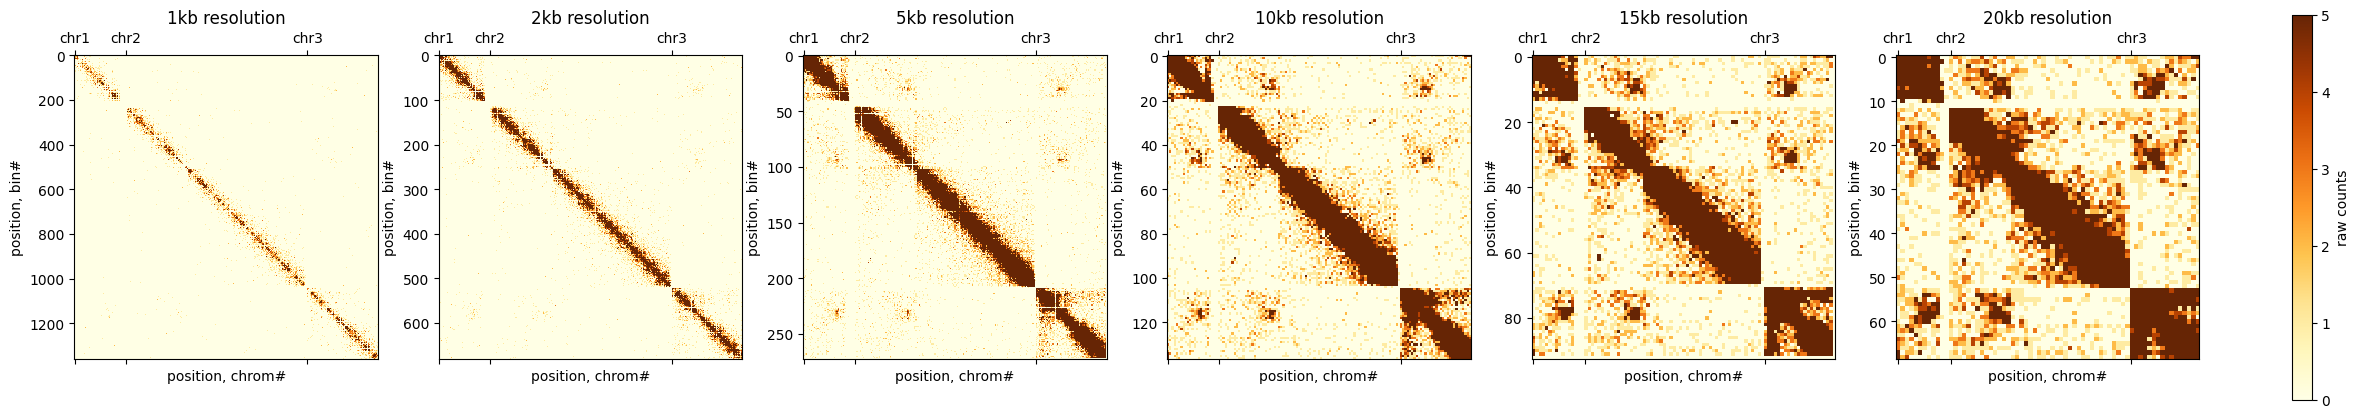

In [16]:
# get list of resolutions in mcool file
res = cooler.fileops.list_coolers(mcool_file)

chrs=["chr1", "chr2", "chr3"] # (consecutive) chr to plot

f,axs = plt.subplots(figsize=(5*len(res),5), ncols=len(res))
for i,r in enumerate(res):
    # load specific resolution
    c = cooler.Cooler(f'{mcool_file}::{r}')

    # extract bin indices
    exts = [c.extent(ch) for ch in chrs]
    start = np.min(exts)
    end   = np.max(exts)

    # plot
    ax = axs[i]
    im = ax.matshow((c.matrix(balance=False)[start:end, start:end]), vmax=5, cmap=cmap);
    ax.set(xticks=[e[0] for e in exts], xticklabels=chrs,
           xlabel='position, chrom#', ylabel='position, bin#')
    ax.xaxis.set_label_position('bottom')
    ax.set_title(f'{int(c.binsize // 1000)}kb resolution')

# add legend
f.colorbar(im, ax=axs,fraction=0.046, pad=0.04, label='raw counts', cmap=cmap)

f.savefig(str(outputdir + hcs_sample + '_'.join(chrs) + "mcool_plot_per_resolution" + ".pdf"), format="pdf", dpi=300)
f.show()

With larger bins, we naturally have more contacts, which saturates the color scale limit set above.

## Normalization and logging

You may have noticed the `balance=False` option in the calls to the cool matrix up to here, e.g.
```py
c.matrix(balance=False)[start:end, start:end]`
```

This retrieves the raw contact counts from the matrix, without normalization steps (e.g. ICE) that may have been performed on the data.

Aside from normalisation, plotting the contact frequency on a log scale also allows for better visualization of the data.

Let's compare our matrix with these different transformations. Note the scale of each color map.


/tmp/ipykernel_6550/4188218978.py:24: RuntimeWarning: divide by zero encountered in log10
  axs[1].imshow(np.log10(c.matrix(balance=False)[start:end, start:end]),
/tmp/ipykernel_6550/4188218978.py:36: RuntimeWarning: divide by zero encountered in log10
  axs[3].imshow(np.log10(c.matrix(balance=True)[start:end, start:end]),


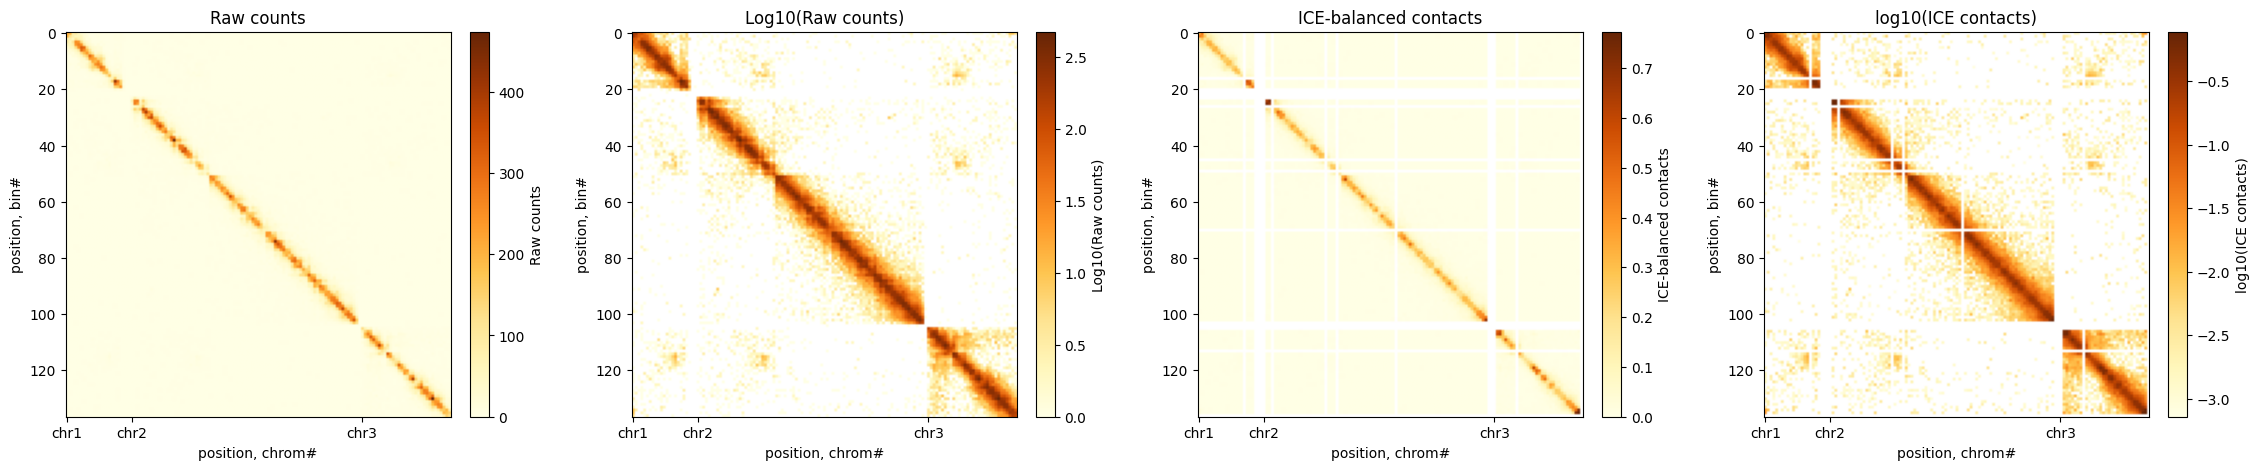

In [17]:
# load cool file at 10kb
c = cooler.Cooler(f'{mcool_file}::resolutions/10000')

# (consecutive) chr to plot
chrs=["chr1", "chr2", "chr3"]

# extract bin indices
exts  = [c.extent(ch) for ch in chrs]
start = np.min(exts)
end   = np.max(exts)

# create plot area
f,axs = plt.subplots(figsize=(4*7,5), ncols=4)
ims = []

# Raw counts
ims.append(
    axs[0].imshow(c.matrix(balance=False)[start:end, start:end],
                  cmap = cmap)#, vmax=20)
)

# Log10 transform
ims.append(
    axs[1].imshow(np.log10(c.matrix(balance=False)[start:end, start:end]),
                  cmap = cmap)#, vmax=np.log10(21))
)

# ICE-normalized
ims.append(
    axs[2].imshow(c.matrix(balance=True)[start:end, start:end],
                  cmap = cmap)
)

# ICE-normalized + Log10 transform
ims.append(
    axs[3].imshow(np.log10(c.matrix(balance=True)[start:end, start:end]),
                  cmap = cmap)
)

labels = ['Raw counts', 'Log10(Raw counts)', 'ICE-balanced contacts', 'log10(ICE contacts)']
# define axes / labels
for i,ax in enumerate(axs):
    ax.set(xticks=[e[0] for e in exts], xticklabels=chrs,
           xlabel='position, chrom#', ylabel='position, bin#')
    ax.xaxis.set_label_position('bottom')
    ax.set_title(labels[i])
    # add legend
    f.colorbar(ims[i] ,fraction=0.046, pad=0.04, label=labels[i])

# save/show
f.savefig(str(outputdir + hcs_sample + '_'.join(chrs) + "_normalization_log_1kb" + ".pdf"), format="pdf", dpi=300)
f.show()


## Bonus:
Plot a log10-normalized Hi-C matrix of all chromosomes in 20kb resolution,

In [18]:
# your code here

/tmp/ipykernel_6550/160424666.py:15: RuntimeWarning: divide by zero encountered in log10
  im = ax.matshow(np.log10(c.matrix(balance=True)[:,:]),


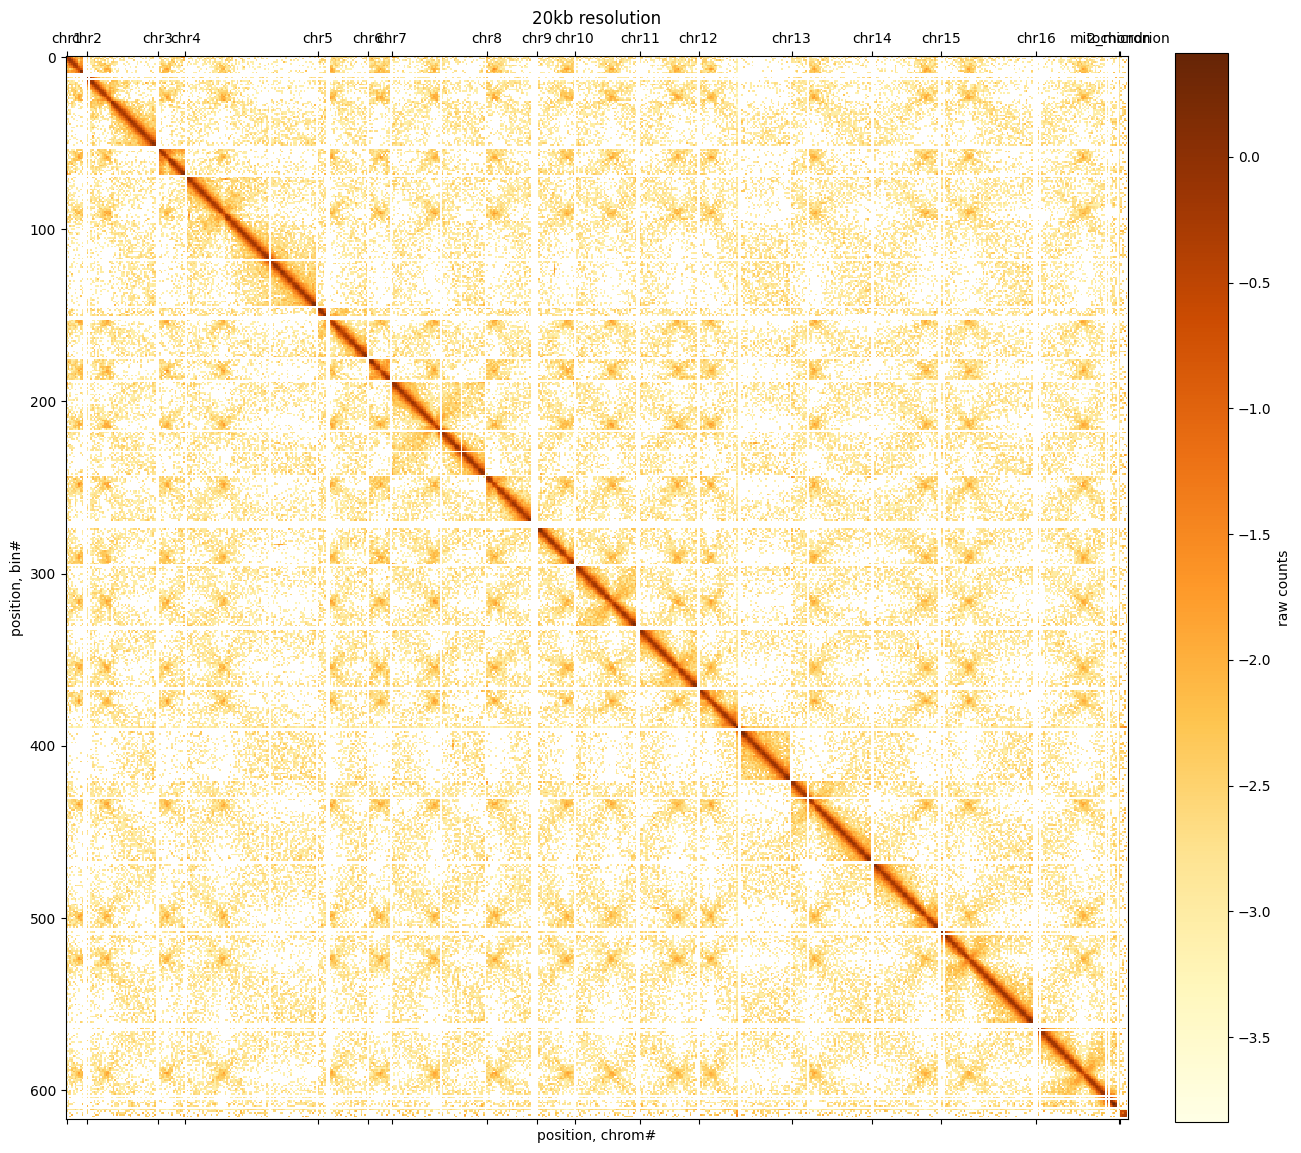

In [19]:
# @title
# Answer

# load 20kb resolution
c = cooler.Cooler(f'{mcool_file}::{res[-1]}')

# fetch chr positions (for labels)
exts = [ c.extent(ch) for ch in c.chromnames ]


# create plot area
f,ax = plt.subplots(figsize=(15,15))

# add matrix
im = ax.matshow(np.log10(c.matrix(balance=True)[:,:]),
                cmap=cmap);
# axes
ax.set(xticks=[e[0] for e in exts], xticklabels=c.chromnames,
       xlabel='position, chrom#', ylabel='position, bin#')
ax.xaxis.set_label_position('bottom')
ax.set_title(f'{int(c.binsize // 1000)}kb resolution')

# add legend
f.colorbar(im, ax=ax,fraction=0.046, pad=0.04, label='raw counts', cmap=cmap)

f.savefig(str(outputdir + hcs_sample + '_'.join(chrs) + f"_full_genome_{int(c.binsize // 1000)}kb" + ".pdf"), format="pdf", dpi=300)
f.show()